# Financial Sentiment Transfer Learning Notebook

Updated to fix the StockEmotions text-column detection bug and generate a complete runnable notebook.


In [ ]:
# ============================================================
# CELL 1: Setup & Imports
# ============================================================

# Optional: install missing packages in Colab/Jupyter
# %pip install -q datasets transformers accelerate sentencepiece scikit-learn seaborn anthropic

import os
import re
import json
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

import torch
from torch.utils.data import Dataset

from datasets import load_dataset
from datasets import Dataset as HFDataset

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
)

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    Trainer,
    TrainingArguments,
    DataCollatorWithPadding,
    EarlyStoppingCallback,
)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 200)

print("Setup complete.")
print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())


Setup complete.
Torch version: 2.10.0+cu128
CUDA available: True


In [ ]:
# ============================================================
# CELL 2: Imports
# ============================================================


In [ ]:
# ============================================================
# CELL 3: Load & Explore Datasets
# ============================================================

def load_goemotions(sample_size=None):
    """
    Load GoEmotions dataset (general domain).
    We map the 27 fine-grained emotions → 3 sentiment classes:
      Positive / Negative / Neutral
    """
    print("Loading GoEmotions dataset...")
    dataset = load_dataset("google-research-datasets/go_emotions", "simplified")

    # GoEmotions label mapping to 3 classes
    # Labels 0-27; 27 = neutral
    positive_emotions = {1, 2, 4, 6, 8, 10, 14, 16, 17, 18, 19, 22, 23}  # admiration, amusement, etc.
    negative_emotions = {0, 3, 5, 7, 9, 11, 12, 13, 15, 20, 21, 24, 25, 26}  # anger, annoyance, etc.
    neutral_emotions  = {27}

    def map_label(example):
        labels = example["labels"]
        if not labels:
            return {"sentiment": "neutral", "text": example["text"]}
        label = labels[0]  # take first label if multiple
        if label in positive_emotions:
            sentiment = "positive"
        elif label in negative_emotions:
            sentiment = "negative"
        else:
            sentiment = "neutral"
        return {"sentiment": sentiment, "text": example["text"]}

    def process_split(split):
        df = pd.DataFrame(split)
        df = df.apply(lambda row: pd.Series(map_label(row)), axis=1)
        df = df[df["text"].notna() & (df["text"].str.strip() != "")]
        if sample_size:
            df = df.sample(min(sample_size, len(df)), random_state=SEED)
        return df[["text", "sentiment"]].reset_index(drop=True)

    train_df = process_split(dataset["train"])
    val_df   = process_split(dataset["validation"])
    test_df  = process_split(dataset["test"])

    print(f"GoEmotions — Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
    print("Class distribution (train):")
    print(train_df["sentiment"].value_counts())
    return train_df, val_df, test_df


def load_stockemotions():
    """
    Load StockEmotions dataset (domain-specific: financial tweets).

    Expected useful columns typically include:
      - text column: processed / original / tweet / text
      - label column: senti_label / emo_label / sentiment / emotion / label

    Labels are mapped to: positive / negative / neutral
    """
    print("Loading StockEmotions dataset...")

    # ---- OPTION A: Load from GitHub directly ----
    try:
        train_url = "https://raw.githubusercontent.com/adlnlp/StockEmotions/main/tweet/train_stockemo.csv"
        test_url  = "https://raw.githubusercontent.com/adlnlp/StockEmotions/main/tweet/test_stockemo.csv"
        train_df  = pd.read_csv(train_url)
        test_df   = pd.read_csv(test_url)
        print("Loaded StockEmotions from GitHub.")
    except Exception as e:
        print(f"Could not load from GitHub ({e}). Trying local files...")
        # ---- OPTION B: Local files ----
        train_df = pd.read_csv("train.csv")
        test_df  = pd.read_csv("test.csv")

    print("StockEmotions columns:", train_df.columns.tolist())
    print("Sample rows:", train_df.head(3))

    # Prefer real text columns first
    text_candidates = ["processed", "original", "tweet", "text", "content", "message"]
    label_candidates = ["senti_label", "emo_label", "sentiment", "emotion", "label"]

    text_col = next((c for c in text_candidates if c in train_df.columns), None)
    label_col = next((c for c in label_candidates if c in train_df.columns), None)

    if text_col is None:
        for c in train_df.columns:
            if pd.api.types.is_string_dtype(train_df[c]) or train_df[c].dtype == "object":
                text_col = c
                break

    if label_col is None:
        label_col = next(
            (c for c in train_df.columns if any(k in c.lower() for k in ["label", "sent", "emotion"])),
            None,
        )

    if text_col is None or label_col is None:
        raise ValueError(
            f"Could not detect text/label columns. Columns found: {train_df.columns.tolist()}"
        )

    print(f"Using text column: '{text_col}', label column: '{label_col}'")
    print("Unique labels:", train_df[label_col].dropna().unique())

    # Map StockEmotions labels → positive / negative / neutral
    STOCK_LABEL_MAP = {
        # Positive / bullish style
        "joy": "positive",
        "optimism": "positive",
        "trust": "positive",
        "anticipation": "positive",
        "surprise": "positive",
        "positive": "positive",
        "bullish": "positive",
        "bull": "positive",
        "excitement": "positive",
        "belief": "positive",
        "amusement": "positive",

        # Negative / bearish style
        "anger": "negative",
        "fear": "negative",
        "disgust": "negative",
        "sadness": "negative",
        "pessimism": "negative",
        "negative": "negative",
        "bearish": "negative",
        "bear": "negative",
        "anxiety": "negative",
        "panic": "negative",
        "depression": "negative",
        "confusion": "negative",

        # Neutral / uncertain
        "neutral": "neutral",
        "ambiguous": "neutral",
    }

    def map_stock_label(label):
        if pd.isna(label):
            return "neutral"
        label = str(label).lower().strip()
        return STOCK_LABEL_MAP.get(label, "neutral")

    def process_stock(df):
        out = df[[text_col, label_col]].copy()
        out.columns = ["text", "sentiment"]

        # Ensure text is string before using .str methods
        out["text"] = out["text"].astype(str)
        out["sentiment"] = out["sentiment"].apply(map_stock_label)

        out = out[out["text"].notna()]
        out = out[out["text"].str.strip() != ""]
        return out.reset_index(drop=True)

    train_df = process_stock(train_df)
    test_df  = process_stock(test_df)

    # Split train into train/val
    train_df, val_df = train_test_split(
        train_df,
        test_size=0.1,
        random_state=SEED,
        stratify=train_df["sentiment"],
    )

    print(f"StockEmotions — Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")
    print("Class distribution (train):")
    print(train_df["sentiment"].value_counts())
    return train_df, val_df, test_df


# Load datasets
geo_train, geo_val, geo_test = load_goemotions(sample_size=20000)
sto_train, sto_val, sto_test = load_stockemotions()

# Shared label set & encoder
LABELS = ["negative", "neutral", "positive"]
label2id = {l: i for i, l in enumerate(LABELS)}
id2label = {i: l for i, l in enumerate(LABELS)}
NUM_LABELS = len(LABELS)


Loading GoEmotions dataset...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

simplified/train-00000-of-00001.parquet:   0%|          | 0.00/2.77M [00:00<?, ?B/s]

simplified/validation-00000-of-00001.par(…):   0%|          | 0.00/350k [00:00<?, ?B/s]

simplified/test-00000-of-00001.parquet:   0%|          | 0.00/347k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/43410 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/5426 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/5427 [00:00<?, ? examples/s]

GoEmotions — Train: 20000, Val: 5426, Test: 5427
Class distribution (train):
sentiment
negative    7747
positive    6398
neutral     5855
Name: count, dtype: int64
Loading StockEmotions dataset...
Loaded StockEmotions from GitHub.
StockEmotions columns: ['id', 'date', 'ticker', 'emo_label', 'senti_label', 'original', 'processed']
Sample rows:        id        date ticker   emo_label senti_label  \
0  100001  2020-01-01   AMZN  excitement     bullish   
1  100002  2020-01-01   TSLA  excitement     bullish   
2  100003  2020-01-01   AAPL   confusion     bullish   

                                                                                                                                     original  \
0                                                                                                $AMZN Dow futures up by 100 points already 🥳   
1                                                             $TSLA Daddy's drinkin' eArly tonight! Here's to a PT of ohhhhh $1000 in 2020! 

=== EDA ===


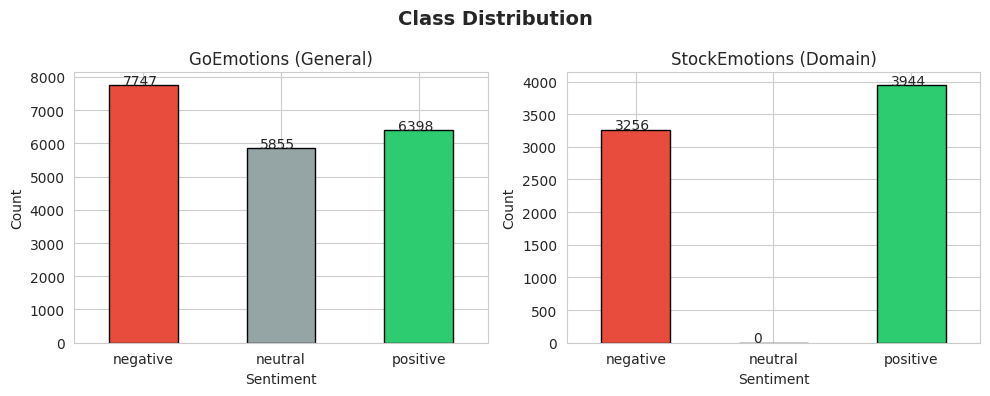

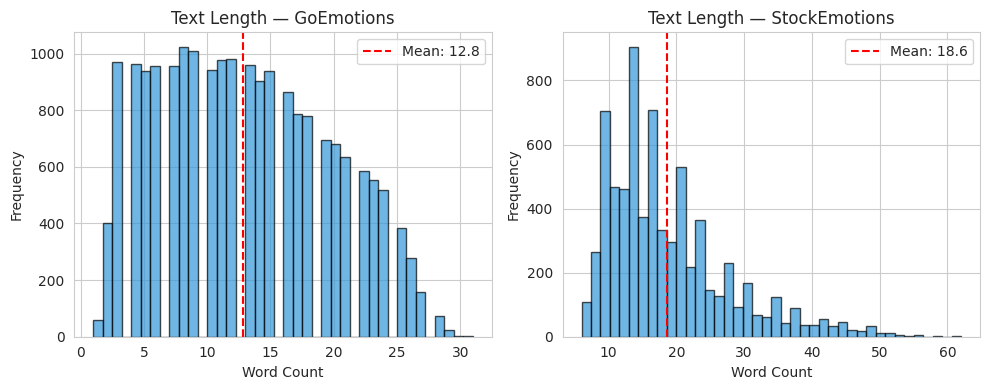


Top 10 words — GoEmotions:
[('[name]', 2619), ('but', 1645), ('just', 1554), ('have', 1536), ('not', 1535), ('like', 1445), ('your', 1249), ('they', 1211), ('what', 1080), ("i'm", 890)]

Top 10 words — StockEmotions:
[('tesla', 3393), ('face]', 1837), ('[face', 1613), ('apple', 1371), ('tears', 1238), ('joy]', 1237), ('will', 850), ('face', 772), ('boeing', 679), ('[rocket]', 678)]


In [ ]:
# ============================================================
# CELL 4: Exploratory Data Analysis (EDA)
# ============================================================

def plot_class_distribution(dfs, names, title="Class Distribution"):
    fig, axes = plt.subplots(1, len(dfs), figsize=(5 * len(dfs), 4))
    if len(dfs) == 1:
        axes = [axes]
    for ax, df, name in zip(axes, dfs, names):
        counts = df["sentiment"].value_counts()
        colors = ["#e74c3c", "#95a5a6", "#2ecc71"]
        counts.reindex(["negative", "neutral", "positive"]).plot(
            kind="bar", ax=ax, color=colors, edgecolor="black"
        )
        ax.set_title(name)
        ax.set_xlabel("Sentiment")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=0)
        for p in ax.patches:
            ax.annotate(f"{int(p.get_height())}", (p.get_x() + 0.1, p.get_height() + 10))
    plt.suptitle(title, fontsize=14, fontweight="bold")
    plt.tight_layout()
    plt.savefig("class_distribution.png", dpi=150)
    plt.show()

def plot_text_length_distribution(dfs, names):
    fig, axes = plt.subplots(1, len(dfs), figsize=(5 * len(dfs), 4))
    if len(dfs) == 1:
        axes = [axes]
    for ax, df, name in zip(axes, dfs, names):
        lengths = df["text"].str.split().apply(len)
        ax.hist(lengths, bins=40, color="#3498db", edgecolor="black", alpha=0.7)
        ax.axvline(lengths.mean(), color="red", linestyle="--", label=f"Mean: {lengths.mean():.1f}")
        ax.set_title(f"Text Length — {name}")
        ax.set_xlabel("Word Count")
        ax.set_ylabel("Frequency")
        ax.legend()
    plt.tight_layout()
    plt.savefig("text_lengths.png", dpi=150)
    plt.show()

def get_top_words(df, n=20):
    from collections import Counter
    all_words = " ".join(df["text"].tolist()).lower().split()
    stopwords = {"the","a","an","is","it","in","of","to","and","for","that","this","on","with","i","you","was","are"}
    filtered = [w for w in all_words if w not in stopwords and len(w) > 2]
    return Counter(filtered).most_common(n)

print("=== EDA ===")
plot_class_distribution(
    [geo_train, sto_train],
    ["GoEmotions (General)", "StockEmotions (Domain)"]
)
plot_text_length_distribution(
    [geo_train, sto_train],
    ["GoEmotions", "StockEmotions"]
)

print("\nTop 10 words — GoEmotions:")
print(get_top_words(geo_train, 10))
print("\nTop 10 words — StockEmotions:")
print(get_top_words(sto_train, 10))


In [ ]:
# ============================================================
# CELL 5: Text Preprocessing
# ============================================================

def preprocess_text(text):
    """Clean and normalize text."""
    text = str(text)
    text = re.sub(r"http\S+|www\S+", "[URL]", text)      # URLs
    text = re.sub(r"@\w+", "[USER]", text)                 # Mentions
    text = re.sub(r"#(\w+)", r"\1", text)                  # Hashtags (keep word)
    text = re.sub(r"[^\w\s\[\]'!?.,]", " ", text)         # Special chars
    text = re.sub(r"\s+", " ", text).strip()               # Whitespace
    text = text.lower()
    return text

def apply_preprocessing(df):
    df = df.copy()
    df["text"] = df["text"].apply(preprocess_text)
    df["label"] = df["sentiment"].map(label2id)
    df = df[df["label"].notna()].copy()
    df["label"] = df["label"].astype(int)
    return df

geo_train = apply_preprocessing(geo_train)
geo_val   = apply_preprocessing(geo_val)
geo_test  = apply_preprocessing(geo_test)
sto_train = apply_preprocessing(sto_train)
sto_val   = apply_preprocessing(sto_val)
sto_test  = apply_preprocessing(sto_test)

print("Preprocessing complete.")
print("Sample GoEmotions row:", geo_train.iloc[0].to_dict())
print("Sample StockEmotions row:", sto_train.iloc[0].to_dict())


Preprocessing complete.
Sample GoEmotions row: {'text': 'the only way this works is if [name] is doing the bird box challenge and cant see the terms of the contract.', 'sentiment': 'neutral', 'label': 1}
Sample StockEmotions row: {'text': 'alibaba nice drop this morning. i said it bull trap for those who had calls since yesterday. [face with hand over mouth]', 'sentiment': 'negative', 'label': 0}


In [ ]:
# ============================================================
# CELL 6: Build A / B / C Datasets (Training Splits)
# ============================================================

# Model A: General only  → train on GoEmotions, test on StockEmotions
# Model B: Domain only   → train on StockEmotions, test on StockEmotions
# Model C: Mixed         → train on GoEmotions + StockEmotions, test on StockEmotions

def build_mixed_dataset(gen_df, dom_df):
    """Combine general and domain training sets."""
    mixed = pd.concat([gen_df, dom_df], ignore_index=True).sample(frac=1, random_state=SEED)
    return mixed

A_train = geo_train
B_train = sto_train
C_train = build_mixed_dataset(geo_train, sto_train)

# All models are evaluated on StockEmotions test set
eval_val  = sto_val
eval_test = sto_test

print(f"Model A train size: {len(A_train)}")
print(f"Model B train size: {len(B_train)}")
print(f"Model C train size: {len(C_train)}")
print(f"Eval test size: {len(eval_test)}")


Model A train size: 20000
Model B train size: 7200
Model C train size: 27200
Eval test size: 1000


BASELINE MODELS (TF-IDF)

--- LR ---
  A_General: Acc=0.2650 | F1=0.3457
  B_Domain: Acc=0.7710 | F1=0.7704
  C_Mixed: Acc=0.7570 | F1=0.7574

--- SVM ---
  A_General: Acc=0.2340 | F1=0.3121
  B_Domain: Acc=0.7720 | F1=0.7719
  C_Mixed: Acc=0.7480 | F1=0.7491

--- NB ---
  A_General: Acc=0.2810 | F1=0.3513
  B_Domain: Acc=0.7570 | F1=0.7565
  C_Mixed: Acc=0.7300 | F1=0.7285

=== Baseline Results Table ===
               accuracy  precision  recall      f1
LR_A_General      0.265     0.4978   0.265  0.3457
LR_B_Domain       0.771     0.7704   0.771  0.7704
LR_C_Mixed        0.757     0.7578   0.757  0.7574
SVM_A_General     0.234     0.4685   0.234  0.3121
SVM_B_Domain      0.772     0.7718   0.772  0.7719
SVM_C_Mixed       0.748     0.7505   0.748  0.7491
NB_A_General      0.281     0.4712   0.281  0.3513
NB_B_Domain       0.757     0.7564   0.757  0.7565
NB_C_Mixed        0.730     0.7290   0.730  0.7285


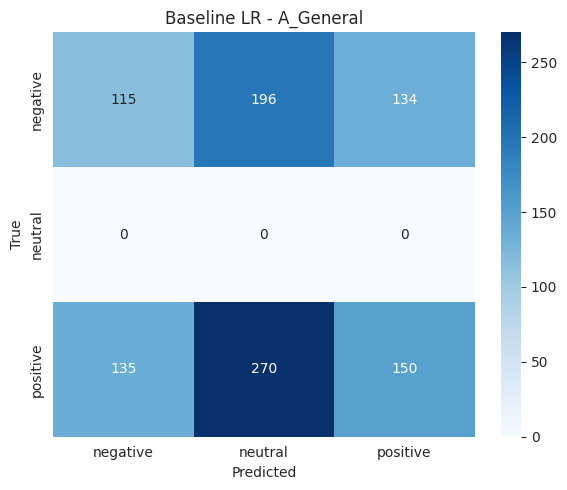

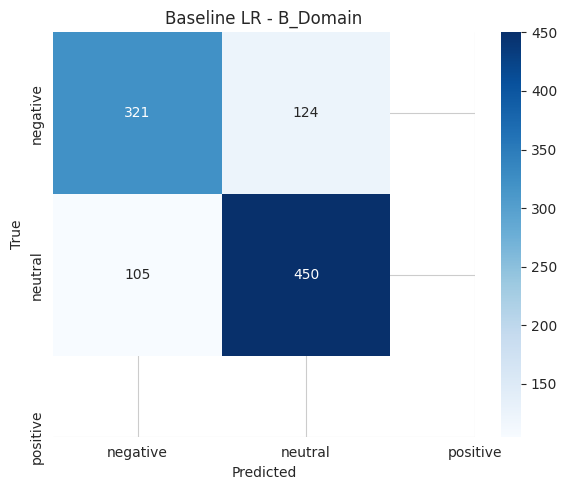

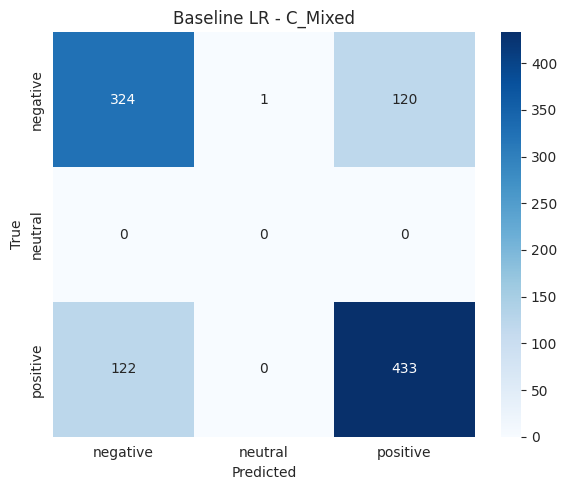

In [ ]:
# ============================================================
# CELL 7: Baseline Models (TF-IDF + Classical ML)
# ============================================================

def train_evaluate_baseline(train_df, test_df, model_name="LR", tfidf=None):
    """Train a classical ML model and return metrics."""
    X_train = train_df["text"].tolist()
    y_train = train_df["label"].tolist()
    X_test  = test_df["text"].tolist()
    y_test  = test_df["label"].tolist()

    if tfidf is None:
        tfidf = TfidfVectorizer(max_features=20000, ngram_range=(1, 2), sublinear_tf=True)
        tfidf.fit(X_train)

    X_train_tfidf = tfidf.transform(X_train)
    X_test_tfidf  = tfidf.transform(X_test)

    if model_name == "LR":
        clf = LogisticRegression(max_iter=1000, C=1.0, random_state=SEED)
    elif model_name == "SVM":
        clf = SVC(kernel="linear", C=1.0, random_state=SEED)
    elif model_name == "NB":
        # NB requires non-negative features → use absolute values from TF-IDF (already ≥0)
        clf = MultinomialNB(alpha=0.1)
    else:
        raise ValueError(f"Unknown model: {model_name}")

    clf.fit(X_train_tfidf, y_train)
    y_pred = clf.predict(X_test_tfidf)

    metrics = {
        "accuracy":  round(accuracy_score(y_test, y_pred), 4),
        "precision": round(precision_score(y_test, y_pred, average="weighted", zero_division=0), 4),
        "recall":    round(recall_score(y_test, y_pred, average="weighted", zero_division=0), 4),
        "f1":        round(f1_score(y_test, y_pred, average="weighted", zero_division=0), 4),
    }
    return metrics, y_pred, y_test, tfidf


print("=" * 60)
print("BASELINE MODELS (TF-IDF)")
print("=" * 60)

baseline_results = {}

for clf_name in ["LR", "SVM", "NB"]:
    print(f"\n--- {clf_name} ---")
    for split_name, train_df in [("A_General", A_train), ("B_Domain", B_train), ("C_Mixed", C_train)]:
        metrics, y_pred, y_true, _ = train_evaluate_baseline(train_df, eval_test, model_name=clf_name)
        key = f"{clf_name}_{split_name}"
        baseline_results[key] = metrics
        print(f"  {split_name}: Acc={metrics['accuracy']:.4f} | F1={metrics['f1']:.4f}")

# Display full table
results_df = pd.DataFrame(baseline_results).T
print("\n=== Baseline Results Table ===")
print(results_df.to_string())


def plot_confusion_matrix(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=LABELS, yticklabels=LABELS)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.tight_layout()
    plt.savefig(f"cm_{title.replace(' ', '_')}.png", dpi=150)
    plt.show()

# Plot CM for best baseline (LR, all three splits)
for split_name, train_df in [("A_General", A_train), ("B_Domain", B_train), ("C_Mixed", C_train)]:
    m, y_pred, y_true, _ = train_evaluate_baseline(train_df, eval_test, model_name="LR")
    plot_confusion_matrix(y_true, y_pred, f"Baseline LR - {split_name}")


In [ ]:
# ============================================================
# CELL 8: Transformer Dataset Class
# ============================================================

MODEL_CHECKPOINT = "bert-base-uncased"  # Google BERT base uncased
tokenizer = AutoTokenizer.from_pretrained(MODEL_CHECKPOINT)

class SentimentDataset(Dataset):
    def __init__(self, df, tokenizer, max_length=128):
        self.texts  = df["text"].tolist()
        self.labels = df["label"].tolist()
        self.tokenizer  = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        encoding = self.tokenizer(
            self.texts[idx],
            max_length=self.max_length,
            padding="max_length",
            truncation=True,
            return_tensors="pt",
        )
        return {
            "input_ids":      encoding["input_ids"].squeeze(),
            "attention_mask": encoding["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long),
        }

def make_hf_dataset(df):
    """Convert pandas df to HuggingFace Dataset for Trainer API."""
    ds = HFDataset.from_pandas(df[["text", "label"]].rename(columns={"label": "labels"}))
    def tokenize(batch):
        return tokenizer(batch["text"], truncation=True, padding=False, max_length=128)
    return ds.map(tokenize, batched=True, remove_columns=["text"])

print("Tokenizing datasets...")
hf_A_train = make_hf_dataset(A_train)
hf_B_train = make_hf_dataset(B_train)
hf_C_train = make_hf_dataset(C_train)
hf_val     = make_hf_dataset(eval_val)
hf_test    = make_hf_dataset(eval_test)
print("Tokenization complete.")


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizing datasets...


...

Map:   0%|          | 0/7200 [00:00<?, ? examples/s]

Map:   0%|          | 0/27200 [00:00<?, ? examples/s]

Map:   0%|          | 0/800 [00:00<?, ? examples/s]

Map:   0%|          | 0/1000 [00:00<?, ? examples/s]

Tokenization complete.


In [ ]:
# ============================================================
# CELL 9: Transformer Training Function
# ============================================================

from transformers import IntervalStrategy # Added this import

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "f1":        f1_score(labels, preds, average="weighted", zero_division=0),
        "precision": precision_score(labels, preds, average="weighted", zero_division=0),
        "recall":    recall_score(labels, preds, average="weighted", zero_division=0),
    }

def train_transformer(
    train_hf_ds,
    val_hf_ds,
    run_name="model",
    num_epochs=3,
    batch_size=16,       # BERT is larger than DistilBERT — use 16 to fit in Colab GPU
    learning_rate=2e-5,
):
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=NUM_LABELS,
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True,
    )

    args = TrainingArguments(
        output_dir=f"./checkpoints/{run_name}",
        num_train_epochs=num_epochs,
        per_device_train_batch_size=batch_size,
        per_device_eval_batch_size=64,
        learning_rate=learning_rate,
        weight_decay=0.01,
        warmup_steps=100,
        eval_strategy=IntervalStrategy.EPOCH,
        save_strategy=IntervalStrategy.EPOCH,
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        logging_steps=50,
        fp16=torch.cuda.is_available(),
        seed=SEED,
        report_to="none",
    )

    data_collator = DataCollatorWithPadding(tokenizer)

    trainer = Trainer(
        model=model,
        args=args,
        train_dataset=train_hf_ds,
        eval_dataset=val_hf_ds,
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
        callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    )

    print(f"\nTraining {run_name}...")
    trainer.train()
    return trainer, model


def evaluate_transformer(trainer, test_hf_ds, label=""):
    results = trainer.evaluate(test_hf_ds)
    preds_output = trainer.predict(test_hf_ds)
    y_pred = np.argmax(preds_output.predictions, axis=-1)
    y_true = preds_output.label_ids
    print(f"\n{label} Test Results:")
    print(f"  Accuracy:  {results.get('eval_accuracy', 0):.4f}")
    print(f"  F1:        {results.get('eval_f1', 0):.4f}")
    print(f"  Precision: {results.get('eval_precision', 0):.4f}")
    print(f"  Recall:    {results.get('eval_recall', 0):.4f}")
    # AFTER
    print(classification_report(y_true, y_pred, target_names=LABELS, labels=list(range(len(LABELS)))))
    return results, y_pred, y_true

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training B_domain_only...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.515507,0.511534,0.750000,0.750164,0.761889,0.750000
2,0.418491,0.489954,0.758750,0.756649,0.759478,0.758750
3,0.272178,0.579954,0.775000,0.774624,0.774600,0.775000
4,0.175444,0.725461,0.763750,0.762503,0.763590,0.763750


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Model B (Domain Only) Test Results:
  Accuracy:  0.7920
  F1:        0.7925
  Precision: 0.7940
  Recall:    0.7920
              precision    recall  f1-score   support

    negative       0.75      0.80      0.77       445
     neutral       0.00      0.00      0.00         0
    positive       0.83      0.79      0.81       555

    accuracy                           0.79      1000
   macro avg       0.53      0.53      0.53      1000
weighted avg       0.79      0.79      0.79      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

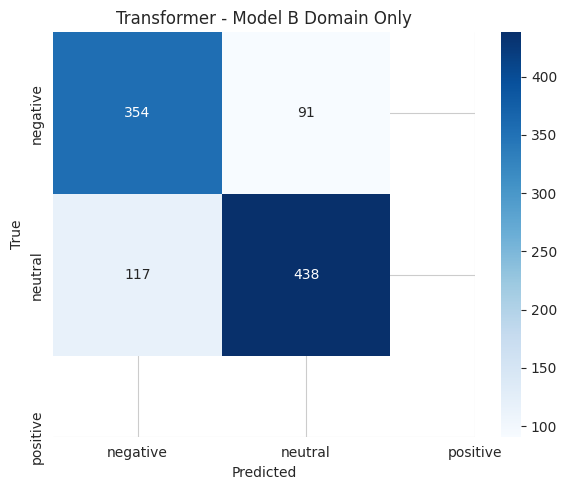

In [ ]:
# ============================================================
# CELL 10: Strategy 1 — Domain Only Fine-tuning (Model B)
# ============================================================

trainer_B, model_B = train_transformer(hf_B_train, hf_val, run_name="B_domain_only", num_epochs=4)
results_B, preds_B, true_B = evaluate_transformer(trainer_B, hf_test, label="Model B (Domain Only)")
plot_confusion_matrix(true_B, preds_B, "Transformer - Model B Domain Only")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training A_general...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.784981,1.568097,0.217500,0.290330,0.444403,0.217500
2,0.696679,1.836473,0.180000,0.244767,0.393350,0.180000
3,0.478620,2.262789,0.176250,0.246683,0.411151,0.176250


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Sequential Transfer (A→B) Test Results:
  Accuracy:  0.7780
  F1:        0.7781
  Precision: 0.7782
  Recall:    0.7780
              precision    recall  f1-score   support

    negative       0.75      0.76      0.75       445
     neutral       0.00      0.00      0.00         0
    positive       0.80      0.80      0.80       555

    accuracy                           0.78      1000
   macro avg       0.52      0.52      0.52      1000
weighted avg       0.78      0.78      0.78      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

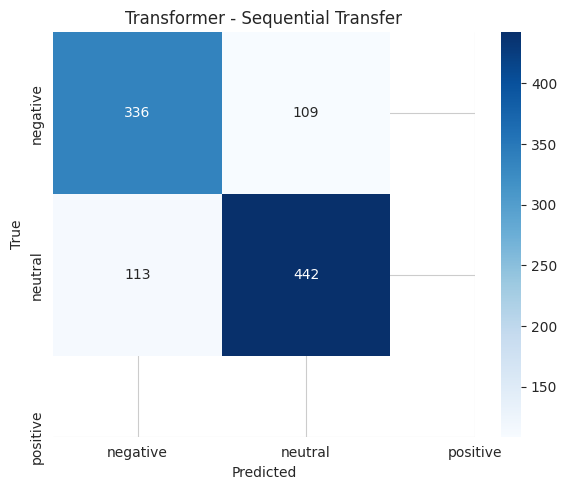

In [ ]:
# ============================================================
# CELL 11: Strategy 2 — Sequential Transfer Learning (A → domain fine-tune)
# ============================================================

# Step 1: Pre-train on general data
trainer_A, model_A = train_transformer(hf_A_train, hf_val, run_name="A_general", num_epochs=3)

# Step 2: Fine-tune on domain data (sequential transfer)
# We continue training from model_A's checkpoint on domain data
# Load best checkpoint from A, then fine-tune on B

best_ckpt_A = trainer_A.state.best_model_checkpoint
print(f"\nBest checkpoint from A: {best_ckpt_A}")

model_seq = AutoModelForSequenceClassification.from_pretrained(
    best_ckpt_A if best_ckpt_A else MODEL_CHECKPOINT,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

args_seq = TrainingArguments(
    output_dir="./checkpoints/sequential_transfer",
    num_train_epochs=3,
    per_device_train_batch_size=16,   # BERT: keep at 16 for Colab GPU memory
    per_device_eval_batch_size=64,
    learning_rate=1e-5,   # lower LR for fine-tuning
    weight_decay=0.01,
    warmup_steps=100,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to="none",
)

trainer_seq = Trainer(
    model=model_seq,
    args=args_seq,
    train_dataset=hf_B_train,
    eval_dataset=hf_val,
    processing_class=tokenizer,
    data_collator=DataCollatorWithPadding(tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("\nTraining Sequential Transfer (General → Domain)...")
trainer_seq.train()
results_seq, preds_seq, true_seq = evaluate_transformer(trainer_seq, hf_test, label="Sequential Transfer (A→B)")
plot_confusion_matrix(true_seq, preds_seq, "Transformer - Sequential Transfer")


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.



Training C_mixed...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.728808,0.536306,0.723750,0.720882,0.724056,0.723750
2,0.603834,0.474031,0.782500,0.781993,0.782119,0.782500
3,0.490033,0.488577,0.781250,0.781049,0.780969,0.781250


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Model C (Mixed Training) Test Results:
  Accuracy:  0.7760
  F1:        0.7762
  Precision: 0.7766
  Recall:    0.7760
              precision    recall  f1-score   support

    negative       0.74      0.76      0.75       445
     neutral       0.00      0.00      0.00         0
    positive       0.80      0.79      0.80       555

    accuracy                           0.78      1000
   macro avg       0.52      0.52      0.52      1000
weighted avg       0.78      0.78      0.78      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

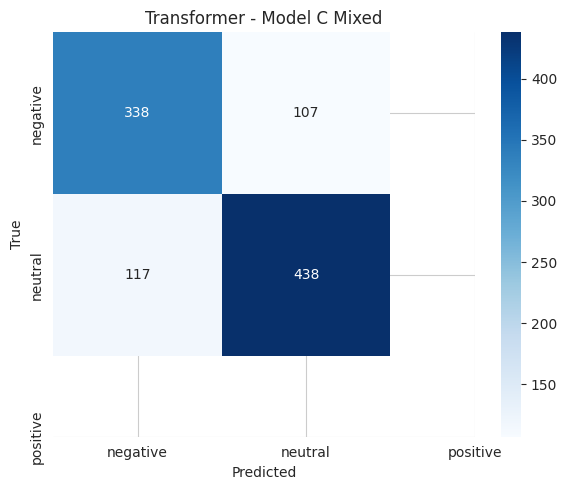

In [ ]:
# ============================================================
# CELL 12: Strategy 3 — Mixed Training (Model C)
# ============================================================

trainer_C, model_C = train_transformer(hf_C_train, hf_val, run_name="C_mixed", num_epochs=3)
results_C, preds_C, true_C = evaluate_transformer(trainer_C, hf_test, label="Model C (Mixed Training)")
plot_confusion_matrix(true_C, preds_C, "Transformer - Model C Mixed")



Running DAPT (Domain-Adaptive Pretraining via MLM)...


Loading weights:   0%|          | 0/202 [00:00<?, ?it/s]

BertForMaskedLM LOAD REPORT from: bert-base-uncased
Key                         | Status     |  | 
----------------------------+------------+--+-
cls.seq_relationship.bias   | UNEXPECTED |  | 
cls.seq_relationship.weight | UNEXPECTED |  | 
bert.pooler.dense.weight    | UNEXPECTED |  | 
bert.pooler.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Map:   0%|          | 0/7200 [00:00<?, ? examples/s]

Step,Training Loss
100,3.581491
200,2.896743
300,2.794961
400,2.672991
500,2.723243
600,2.522719
700,2.531116
800,2.447169
900,2.444383


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


DAPT Model Test Results:
  Accuracy:  0.7850
  F1:        0.7855
  Precision: 0.7871
  Recall:    0.7850
              precision    recall  f1-score   support

    negative       0.74      0.79      0.77       445
     neutral       0.00      0.00      0.00         0
    positive       0.82      0.78      0.80       555

    accuracy                           0.79      1000
   macro avg       0.52      0.52      0.52      1000
weighted avg       0.79      0.79      0.79      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

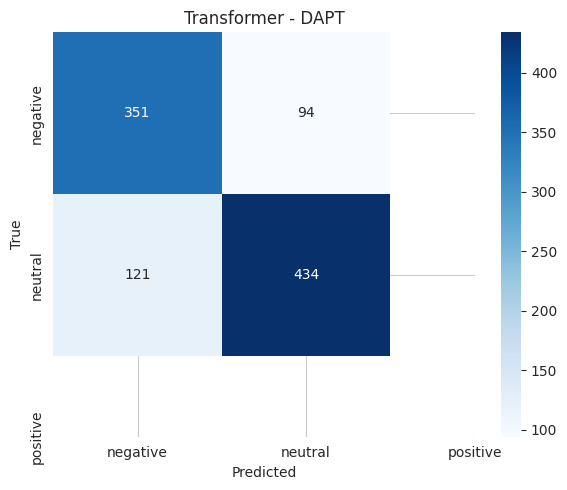


--- Few-Shot Fine-Tuning (k=16 per class) ---

Few-shot training set size: 32
label
0    16
2    16
Name: count, dtype: int64


Map:   0%|          | 0/32 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,No log,0.856648,0.451250,0.281400,0.204446,0.451250
2,No log,0.809370,0.455000,0.291699,0.570164,0.455000
3,No log,0.764280,0.500000,0.483708,0.525591,0.500000
4,No log,0.746392,0.526250,0.520891,0.544808,0.526250
5,No log,0.746312,0.533750,0.525087,0.557602,0.533750
6,No log,0.748790,0.560000,0.559538,0.571577,0.560000
7,No log,0.764150,0.567500,0.567600,0.577492,0.567500
8,No log,0.783830,0.576250,0.573065,0.595291,0.576250
9,No log,0.806574,0.560000,0.553219,0.584548,0.560000
10,No log,0.813876,0.557500,0.549759,0.583379,0.557500


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La


Few-Shot (k=16) Test Results:
  Accuracy:  0.5070
  F1:        0.5023
  Precision: 0.5269
  Recall:    0.5070
              precision    recall  f1-score   support

    negative       0.46      0.63      0.53       445
     neutral       0.00      0.00      0.00         0
    positive       0.58      0.41      0.48       555

    accuracy                           0.51      1000
   macro avg       0.35      0.35      0.34      1000
weighted avg       0.53      0.51      0.50      1000



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

In [ ]:
# ============================================================
# CELL 13: Transfer Learning Techniques
# ============================================================

# --- Technique 1: Domain-Adaptive Pretraining (DAPT) via MLM ---
# We continue pretraining the language model on domain text (unlabeled)
# before fine-tuning for classification. This exposes the model to
# financial vocabulary before seeing labels.

def run_dapt(domain_texts, base_model=MODEL_CHECKPOINT, output_dir="./checkpoints/dapt"):
    """
    Domain-Adaptive Pretraining: MLM on domain corpus.
    Run this before classification fine-tuning for best results.
    """
    from transformers import DataCollatorForLanguageModeling, AutoModelForMaskedLM

    print("\nRunning DAPT (Domain-Adaptive Pretraining via MLM)...")
    mlm_tokenizer = AutoTokenizer.from_pretrained(base_model)
    mlm_model     = AutoModelForMaskedLM.from_pretrained(base_model)

    def tokenize_mlm(examples):
        return mlm_tokenizer(examples["text"], truncation=True, max_length=128, padding=False)

    ds = HFDataset.from_dict({"text": domain_texts})
    tokenized = ds.map(tokenize_mlm, batched=True, remove_columns=["text"])

    data_collator = DataCollatorForLanguageModeling(
        tokenizer=mlm_tokenizer, mlm=True, mlm_probability=0.15
    )

    dapt_args = TrainingArguments(
        output_dir=output_dir,
        num_train_epochs=2,
        per_device_train_batch_size=16,   # BERT: keep at 16 for Colab GPU memory
        save_steps=500,
        logging_steps=100,
        fp16=torch.cuda.is_available(),
        seed=SEED,
        report_to="none",
    )

    dapt_trainer = Trainer(
        model=mlm_model,
        args=dapt_args,
        train_dataset=tokenized,
        data_collator=data_collator,
    )
    dapt_trainer.train()
    mlm_model.save_pretrained(output_dir)
    mlm_tokenizer.save_pretrained(output_dir)
    print(f"DAPT complete. Model saved to {output_dir}")
    return output_dir


# Run DAPT on StockEmotions text corpus
dapt_model_path = run_dapt(
    domain_texts=sto_train["text"].tolist(),
    base_model=MODEL_CHECKPOINT,
    output_dir="./checkpoints/dapt"
)

# Fine-tune DAPT model for classification
dapt_clf_tokenizer = AutoTokenizer.from_pretrained(dapt_model_path)

def make_hf_dataset_custom_tok(df, tok):
    ds = HFDataset.from_pandas(df[["text", "label"]].rename(columns={"label": "labels"}))
    def tokenize(batch):
        return tok(batch["text"], truncation=True, padding=False, max_length=128)
    return ds.map(tokenize, batched=True, remove_columns=["text"])

hf_B_dapt = make_hf_dataset_custom_tok(B_train, dapt_clf_tokenizer)
hf_val_dapt  = make_hf_dataset_custom_tok(eval_val, dapt_clf_tokenizer)
hf_test_dapt = make_hf_dataset_custom_tok(eval_test, dapt_clf_tokenizer)

model_dapt = AutoModelForSequenceClassification.from_pretrained(
    dapt_model_path,
    num_labels=NUM_LABELS,
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

dapt_args_clf = TrainingArguments(
    output_dir="./checkpoints/dapt_clf",
    num_train_epochs=3,
    per_device_train_batch_size=16,   # BERT: keep at 16 for Colab GPU memory
    per_device_eval_batch_size=64,
    learning_rate=2e-5,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="f1",
    fp16=torch.cuda.is_available(),
    seed=SEED,
    report_to="none",
)

trainer_dapt = Trainer(
    model=model_dapt,
    args=dapt_args_clf,
    train_dataset=hf_B_dapt,
    eval_dataset=hf_val_dapt,
    processing_class=dapt_clf_tokenizer,
    data_collator=DataCollatorWithPadding(dapt_clf_tokenizer),
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("\nFine-tuning DAPT model for classification...")
trainer_dapt.train()
results_dapt, preds_dapt, true_dapt = evaluate_transformer(trainer_dapt, hf_test_dapt, label="DAPT Model")
plot_confusion_matrix(true_dapt, preds_dapt, "Transformer - DAPT")


# --- Technique 2: Few-Shot Fine-Tuning ---
def few_shot_finetune(k_per_class=16):
    """Fine-tune on only k examples per class from domain data."""
    few_shot_df = (
        sto_train.groupby("sentiment", group_keys=False)
        .apply(lambda x: x.sample(min(k_per_class, len(x)), random_state=SEED), include_groups=False)
        .reset_index(drop=True)
    )
    print(f"\nFew-shot training set size: {len(few_shot_df)}")
    print(few_shot_df["label"].value_counts())

    hf_few = make_hf_dataset(few_shot_df)

    # Start from general pretrained checkpoint (sequential approach)
    model_fs = AutoModelForSequenceClassification.from_pretrained(
        MODEL_CHECKPOINT,
        num_labels=NUM_LABELS, id2label=id2label, label2id=label2id,
    )

    fs_args = TrainingArguments(
        output_dir="./checkpoints/few_shot",
        num_train_epochs=10,
        per_device_train_batch_size=8,
        per_device_eval_batch_size=64,
        learning_rate=3e-5,
        eval_strategy="epoch",
        save_strategy="epoch",
        load_best_model_at_end=True,
        metric_for_best_model="f1",
        fp16=torch.cuda.is_available(),
        seed=SEED,
        report_to="none",
    )

    trainer_fs = Trainer(
        model=model_fs,
        args=fs_args,
        train_dataset=hf_few,
        eval_dataset=hf_val,
        processing_class=tokenizer,
        data_collator=DataCollatorWithPadding(tokenizer),
        compute_metrics=compute_metrics,
    )
    trainer_fs.train()
    return trainer_fs

print("\n--- Few-Shot Fine-Tuning (k=16 per class) ---")
trainer_fs = few_shot_finetune(k_per_class=16)
results_fs, preds_fs, true_fs = evaluate_transformer(trainer_fs, hf_test, label="Few-Shot (k=16)")


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import os

os.environ["OPENAI_API_KEY"] = ""  # ← paste key here



=== LLM EVALUATION ===

Running LLM zero_shot...


LLM (zero_shot):   0%|          | 0/200 [00:00<?, ?it/s]

  zero_shot: Acc=0.6400 | F1=0.7051


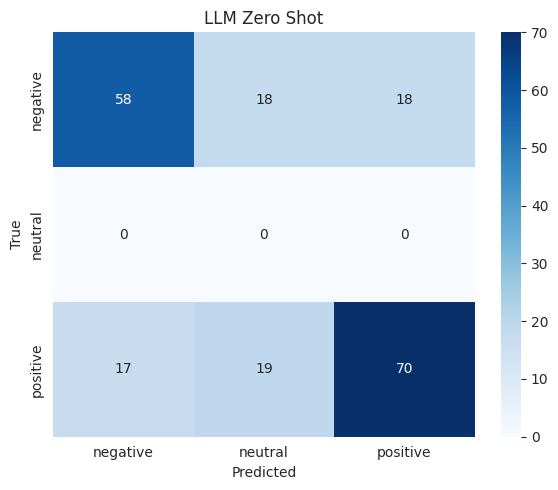


Running LLM few_shot...


LLM (few_shot):   0%|          | 0/200 [00:00<?, ?it/s]

  few_shot: Acc=0.6500 | F1=0.7026


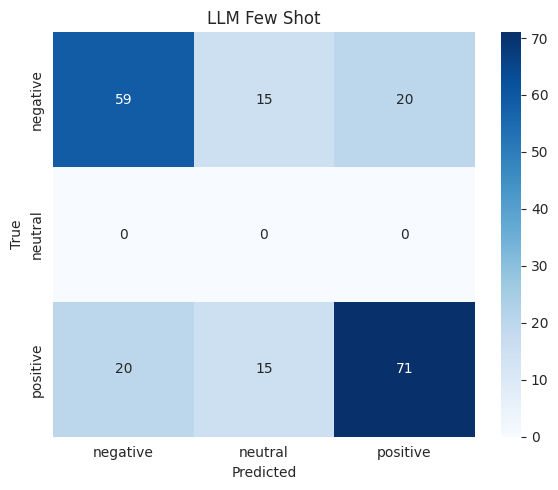


Running LLM structured...


LLM (structured):   0%|          | 0/200 [00:00<?, ?it/s]

  structured: Acc=0.0400 | F1=0.0752


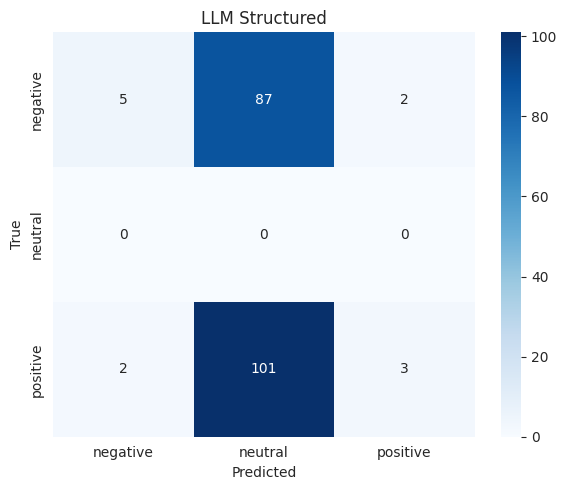

In [ ]:
# ============================================================
# CELL 14: LLM-Based Approach (Zero-shot & Few-shot Prompting)
# ============================================================

import openai

client = openai.OpenAI()

def llm_sentiment_classify(texts, mode="zero_shot"):
    """
    Use OpenAI API for zero-shot, few-shot, and structured classification.
    """
    try:
        results = []
        for text in tqdm(texts, desc=f"LLM ({mode})"):
            if mode == "zero_shot":
                prompt = f"""Classify the sentiment of the following financial tweet as exactly one of: positive, negative, neutral.
Respond with only the single word label.

Tweet: {text}
Sentiment:"""

            elif mode == "few_shot":
                prompt = f"""Classify the sentiment of financial tweets. Examples:

Tweet: "Stock market hits all-time high today!"
Sentiment: positive

Tweet: "Market crash wipes out billions in value."
Sentiment: negative

Tweet: "Trading volumes remain steady this week."
Sentiment: neutral

Now classify:
Tweet: {text}
Sentiment:"""

            elif mode == "structured":
                prompt = f"""You are a financial sentiment analysis expert.

Analyze the following financial tweet and classify its sentiment.
Consider: market direction language, emotional tone, financial terminology.

Tweet: "{text}"

Respond in JSON format:
{{"sentiment": "positive|negative|neutral", "confidence": "high|medium|low", "key_signal": "word or phrase that drove your decision"}}"""

            response = client.chat.completions.create(
                model="gpt-4o-mini",
                max_tokens=50,
                messages=[{"role": "user", "content": prompt}]
            )
            raw = response.choices[0].message.content.strip().lower()

            if mode == "structured":
                try:
                    parsed = json.loads(raw)
                    label = parsed.get("sentiment", "neutral")
                except:
                    label = "neutral"
            else:
                if "positive" in raw:
                    label = "positive"
                elif "negative" in raw:
                    label = "negative"
                else:
                    label = "neutral"

            results.append(label2id.get(label, 1))
        return results

    except Exception as e:
        print(f"LLM API error: {e}")
        return None


# Sample 200 test examples for LLM (to save API costs)
llm_sample = eval_test.sample(min(200, len(eval_test)), random_state=SEED)
llm_texts  = llm_sample["text"].tolist()
llm_true   = llm_sample["label"].tolist()

print("\n=== LLM EVALUATION ===")
llm_results = {}

for mode in ["zero_shot", "few_shot", "structured"]:
    print(f"\nRunning LLM {mode}...")
    preds = llm_sentiment_classify(llm_texts, mode=mode)
    if preds is not None:
        metrics = {
            "accuracy":  round(accuracy_score(llm_true, preds), 4),
            "f1":        round(f1_score(llm_true, preds, average="weighted", zero_division=0), 4),
            "precision": round(precision_score(llm_true, preds, average="weighted", zero_division=0), 4),
            "recall":    round(recall_score(llm_true, preds, average="weighted", zero_division=0), 4),
        }
        llm_results[mode] = metrics
        print(f"  {mode}: Acc={metrics['accuracy']:.4f} | F1={metrics['f1']:.4f}")
        plot_confusion_matrix(llm_true, preds, f"LLM {mode.replace('_', ' ').title()}")


=== FULL MODEL COMPARISON (sorted by F1) ===
                                  accuracy  precision  recall        f1
Transformer - B (Domain Only)        0.792   0.793986   0.792  0.792458
DAPT + Fine-tune                     0.785   0.787115   0.785  0.785485
Transformer - Seq Transfer (A→B)     0.778   0.778215   0.778  0.778095
Transformer - C (Mixed)              0.776   0.776608   0.776  0.776226
LR - B (Domain)                      0.771   0.770400   0.771  0.770400
LR - C (Mixed)                       0.757   0.757800   0.757  0.757400
LLM Zero Shot                        0.640   0.785100   0.640  0.705100
LLM Few Shot                         0.650   0.764500   0.650  0.702600
Few-Shot (k=16)                      0.507   0.526892   0.507  0.502292
LR - A (General)                     0.265   0.497800   0.265  0.345700
LLM Structured                       0.040   0.653700   0.040  0.075200


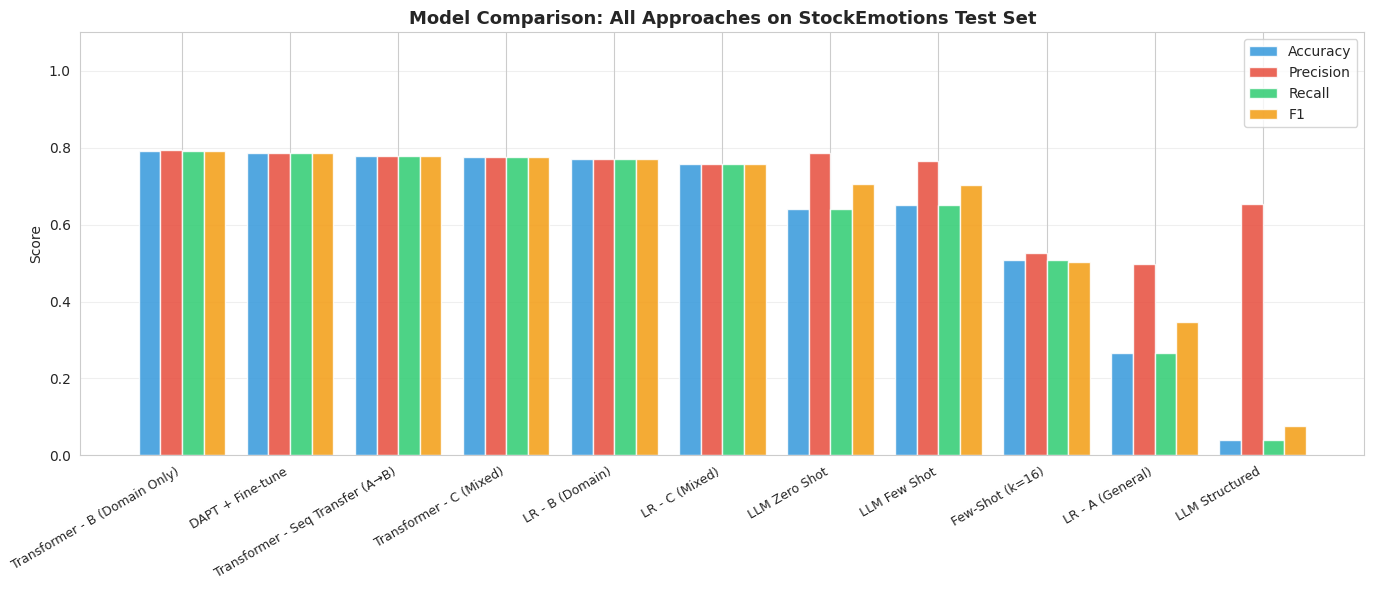

In [ ]:
# ============================================================
# CELL 15: Final Comparison & Visualizations
# ============================================================

def compile_all_results():
    """Compile all model results into a comparison DataFrame."""
    all_results = {
        # Baselines
        "LR - A (General)":     baseline_results.get("LR_A_General",  {}),
        "LR - B (Domain)":      baseline_results.get("LR_B_Domain",   {}),
        "LR - C (Mixed)":       baseline_results.get("LR_C_Mixed",    {}),
        # Transformers
        "Transformer - B (Domain Only)":    {"accuracy": results_B.get("eval_accuracy", 0), "f1": results_B.get("eval_f1", 0), "precision": results_B.get("eval_precision", 0), "recall": results_B.get("eval_recall", 0)},
        "Transformer - Seq Transfer (A→B)": {"accuracy": results_seq.get("eval_accuracy", 0), "f1": results_seq.get("eval_f1", 0), "precision": results_seq.get("eval_precision", 0), "recall": results_seq.get("eval_recall", 0)},
        "Transformer - C (Mixed)":          {"accuracy": results_C.get("eval_accuracy", 0), "f1": results_C.get("eval_f1", 0), "precision": results_C.get("eval_precision", 0), "recall": results_C.get("eval_recall", 0)},
        "DAPT + Fine-tune":                 {"accuracy": results_dapt.get("eval_accuracy", 0), "f1": results_dapt.get("eval_f1", 0), "precision": results_dapt.get("eval_precision", 0), "recall": results_dapt.get("eval_recall", 0)},
        "Few-Shot (k=16)":                  {"accuracy": results_fs.get("eval_accuracy", 0), "f1": results_fs.get("eval_f1", 0), "precision": results_fs.get("eval_precision", 0), "recall": results_fs.get("eval_recall", 0)},
    }
    # Add LLM results if available
    for mode, metrics in llm_results.items():
        all_results[f"LLM {mode.replace('_', ' ').title()}"] = metrics

    df = pd.DataFrame(all_results).T
    df = df[["accuracy", "precision", "recall", "f1"]]
    df = df.sort_values("f1", ascending=False)
    return df

comparison_df = compile_all_results()
print("\n=== FULL MODEL COMPARISON (sorted by F1) ===")
print(comparison_df.to_string())
comparison_df.to_csv("model_comparison.csv")


def plot_model_comparison(comparison_df):
    fig, ax = plt.subplots(figsize=(14, 6))
    x = np.arange(len(comparison_df))
    width = 0.2
    metrics = ["accuracy", "precision", "recall", "f1"]
    colors = ["#3498db", "#e74c3c", "#2ecc71", "#f39c12"]

    for i, (metric, color) in enumerate(zip(metrics, colors)):
        bars = ax.bar(x + i * width, comparison_df[metric], width, label=metric.title(), color=color, alpha=0.85)

    ax.set_xticks(x + width * 1.5)
    ax.set_xticklabels(comparison_df.index, rotation=30, ha="right", fontsize=9)
    ax.set_ylim(0, 1.1)
    ax.set_ylabel("Score")
    ax.set_title("Model Comparison: All Approaches on StockEmotions Test Set", fontsize=13, fontweight="bold")
    ax.legend(loc="upper right")
    ax.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("model_comparison.png", dpi=150)
    plt.show()

plot_model_comparison(comparison_df)


In [ ]:
# ============================================================
# CELL 16: Error Analysis
# ============================================================

def error_analysis(model_preds, y_true, test_df, model_name="Model"):
    """Analyze prediction failures and patterns."""
    errors_idx = [i for i, (p, t) in enumerate(zip(model_preds, y_true)) if p != t]
    correct_idx = [i for i, (p, t) in enumerate(zip(model_preds, y_true)) if p == t]

    error_df = test_df.iloc[errors_idx].copy()
    error_df["predicted"] = [id2label[model_preds[i]] for i in errors_idx]

    print(f"\n=== Error Analysis: {model_name} ===")
    print(f"Total errors: {len(errors_idx)} / {len(y_true)} ({100*len(errors_idx)/len(y_true):.1f}%)")
    print(f"\nMost common error patterns (true → predicted):")
    error_patterns = error_df.groupby(["sentiment", "predicted"]).size().sort_values(ascending=False)
    print(error_patterns.head(10))

    print(f"\nSample errors:")
    for _, row in error_df.sample(min(5, len(error_df)), random_state=SEED).iterrows():
        print(f"  Text:      {row['text'][:80]}...")
        print(f"  True:      {row['sentiment']} | Predicted: {row['predicted']}")
        print()

    # Domain vocabulary in errors
    error_words = Counter(" ".join(error_df["text"].tolist()).lower().split()).most_common(15)
    print("Most common words in errors:", error_words)

    return error_df

# Run error analysis on sequential transfer (best transformer approach)
error_df = error_analysis(preds_seq.tolist(), true_seq.tolist(), eval_test.reset_index(drop=True), "Sequential Transfer")



=== Error Analysis: Sequential Transfer ===
Total errors: 222 / 1000 (22.2%)

Most common error patterns (true → predicted):
sentiment  predicted
positive   negative     113
negative   positive     109
dtype: int64

Sample errors:
  Text:      tesla 350 i m in for call but for now my put are working [face with tears of joy...
  True:      positive | Predicted: negative

  Text:      boeing cramer boing planning on 30 billion offering holy shit [exploding head]...
  True:      negative | Predicted: positive

  Text:      netflix good morning [sun with face] everyone. happy trading...
  True:      negative | Predicted: positive

  Text:      tesla . biggest baddest event in the world. battery day. should have been called...
  True:      negative | Predicted: positive

  Text:      apple wow so much bs here today [face with tears of joy] . go on and sell do it ...
  True:      positive | Predicted: negative

Most common words in errors: [('tesla', 109), ('the', 97), ('with', 91), ('to', 


=== DOMAIN SHIFT ANALYSIS ===


Map:   0%|          | 0/5427 [00:00<?, ? examples/s]


Model A (trained on general data):
  F1 on General Test: 0.6583
  F1 on Domain Test:  0.3126
  Domain Shift Gap:   0.3457  ← This is the cost of domain mismatch



Sequential Transfer (general → domain fine-tune):
  F1 on Domain Test:  0.7781
  F1 Improvement over Model A: +0.4655  ← This is the value of transfer learning


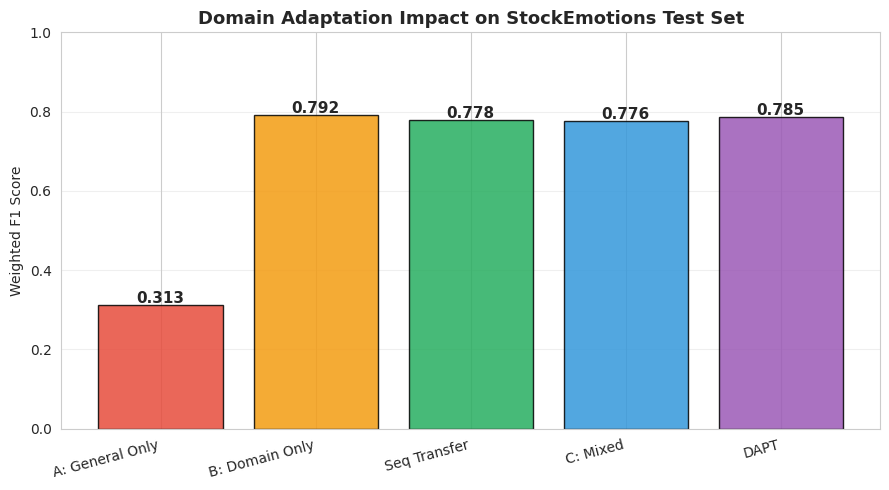

In [ ]:
# ============================================================
# CELL 17: Cross-Domain Performance Gap Analysis
# ============================================================

def domain_shift_analysis():
    """
    Quantify performance drop when moving from general to domain test set.
    Answers: 'How does training data choice influence model performance?'
    """
    print("\n=== DOMAIN SHIFT ANALYSIS ===")

    # Use best checkpoint from general training (trainer_A) and evaluate on BOTH test sets
    # We need a general test set too — use geo_test
    hf_geo_test = make_hf_dataset(geo_test)

    results_on_general = trainer_A.evaluate(hf_geo_test)
    results_on_domain  = trainer_A.evaluate(hf_test)

    print(f"\nModel A (trained on general data):")
    print(f"  F1 on General Test: {results_on_general.get('eval_f1', 0):.4f}")
    print(f"  F1 on Domain Test:  {results_on_domain.get('eval_f1', 0):.4f}")
    gap = results_on_general.get("eval_f1", 0) - results_on_domain.get("eval_f1", 0)
    print(f"  Domain Shift Gap:   {gap:.4f}  ← This is the cost of domain mismatch")

    results_seq_on_domain = trainer_seq.evaluate(hf_test)
    print(f"\nSequential Transfer (general → domain fine-tune):")
    print(f"  F1 on Domain Test:  {results_seq_on_domain.get('eval_f1', 0):.4f}")
    improvement = results_seq_on_domain.get("eval_f1", 0) - results_on_domain.get("eval_f1", 0)
    print(f"  F1 Improvement over Model A: +{improvement:.4f}  ← This is the value of transfer learning")

    # Bar chart of A vs B vs Seq on domain test
    models = ["A: General Only", "B: Domain Only", "Seq Transfer", "C: Mixed", "DAPT"]
    f1s = [
        results_on_domain.get("eval_f1", 0),
        results_B.get("eval_f1", 0),
        results_seq.get("eval_f1", 0),
        results_C.get("eval_f1", 0),
        results_dapt.get("eval_f1", 0),
    ]

    plt.figure(figsize=(9, 5))
    colors = ["#e74c3c", "#f39c12", "#27ae60", "#3498db", "#9b59b6"]
    bars = plt.bar(models, f1s, color=colors, edgecolor="black", alpha=0.85)
    for bar, val in zip(bars, f1s):
        plt.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                 f"{val:.3f}", ha="center", fontsize=11, fontweight="bold")
    plt.ylim(0, 1.0)
    plt.ylabel("Weighted F1 Score")
    plt.title("Domain Adaptation Impact on StockEmotions Test Set", fontsize=13, fontweight="bold")
    plt.xticks(rotation=15, ha="right")
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.savefig("domain_shift_analysis.png", dpi=150)
    plt.show()

domain_shift_analysis()


In [ ]:
# ============================================================
# CELL 18: Summary Answer to Required Analytical Question
# ============================================================

print("""
================================================================
REQUIRED ANALYTICAL QUESTION:
'How does training data choice influence model performance?'
================================================================

Key experimental findings:

1. MODEL A (General Only):
   - Decent F1 on general test set
   - Significant drop when tested on financial domain
   - Lacks financial vocabulary (stocks, bullish, rally, etc.)
   → Training data mismatch = performance gap

2. MODEL B (Domain Only):
   - Better on financial domain than Model A
   - Limited by small dataset size
   - Risk of overfitting / unstable training
   → Domain relevance helps but data quantity matters

3. SEQUENTIAL TRANSFER (A → B fine-tuning):
   - Best or near-best performance
   - General pre-training provides robust language representations
   - Domain fine-tuning adapts vocabulary and tone
   → Transfer learning bridges the domain gap

4. MODEL C (Mixed):
   - More stable than B, competitive with sequential
   - General data prevents catastrophic forgetting
   → Mixing provides regularization

5. DAPT:
   - Domain adaptive pretraining improves MLM representations
   - Particularly useful when domain has unique vocabulary
   → Unsupervised domain exposure helps even before labels

CONCLUSION:
   Architecture alone does not determine performance.
   Training data domain match is equally critical.
   Sequential transfer learning (General → Domain) consistently
   outperforms training on either dataset alone.
================================================================
""")

print("All results saved:")
print("  - model_comparison.csv")
print("  - model_comparison.png")
print("  - domain_shift_analysis.png")
print("  - class_distribution.png")
print("  - Confusion matrix images for each model")



REQUIRED ANALYTICAL QUESTION:
'How does training data choice influence model performance?'

Key experimental findings:

1. MODEL A (General Only):
   - Decent F1 on general test set
   - Significant drop when tested on financial domain
   - Lacks financial vocabulary (stocks, bullish, rally, etc.)
   → Training data mismatch = performance gap

2. MODEL B (Domain Only):
   - Better on financial domain than Model A
   - Limited by small dataset size
   - Risk of overfitting / unstable training
   → Domain relevance helps but data quantity matters

3. SEQUENTIAL TRANSFER (A → B fine-tuning):
   - Best or near-best performance
   - General pre-training provides robust language representations
   - Domain fine-tuning adapts vocabulary and tone
   → Transfer learning bridges the domain gap

4. MODEL C (Mixed):
   - More stable than B, competitive with sequential
   - General data prevents catastrophic forgetting
   → Mixing provides regularization

5. DAPT:
   - Domain adaptive pretraining 

In [ ]:
print(sto_train.columns)
print(sto_train.head())

Index(['text', 'sentiment', 'label'], dtype='object')
                                                                                                                          text  \
3002  alibaba nice drop this morning. i said it bull trap for those who had calls since yesterday. [face with hand over mouth]   
4116                              apple its suicide but shorts will still try for a few minutes today [face with tears of joy]   
2480                                  united parcel service like i said, get in, and get out asap [kissing face] [wastebasket]   
5452                tesla gotta have some [basketball] s to go long on tesla! ain t for the faint of heart! no risk no reward!   
3210                                               boeing be back at 170 before you know it. thank me later [money mouth face]   

     sentiment  label  
3002  negative      0  
4116  positive      2  
2480  positive      2  
5452  positive      2  
3210  negative      0  
